In [87]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import quad

### Part 2

In [88]:
# defining the function to be integrated
def f(x):
    return np.exp(np.cos(x))

# defining limits of integration
a = 0           # lower limit
b = 2 * np.pi   # upper limit

# using built-in quadrature routine to calculate the integral
tol = 1e-10
I_exact, error = quad(f, a, b, epsabs=tol)

print("I_exact: ", I_exact)


I_exact:  7.954926521012844


In [89]:
# function to implement multipoint trapezoidal rule
def trapezoid(a, b, I_exact, N):
    I = (f(a) + f(b))/2.0
    h = (b - a)/N 
    x = np.linspace(a,b,N+1)
    
    for j in range(1,N):
        I = I + f(x[j])
    
    I = h * I 
    error = np.abs(I - I_exact)
    
    return I, error 

------------------------------------------------------------
N 	 	 I 			 error
------------------------------------------------------------
2 	 9.695461572464488 	 1.7405350514516442
3 	 8.23378583475595 	 0.2788593137431068
4 	 7.989323439822037 	 0.034396918809193266
5 	 7.9583378310982 	 0.003411310085356334
6 	 7.955209121874115 	 0.00028260086127129824
7 	 7.9549466173818395 	 2.0096368995581315e-05
8 	 7.954927772701776 	 1.2516889320579594e-06
9 	 7.954926590358927 	 6.934608265396491e-08
10 	 7.954926524472301 	 3.459456721088827e-09


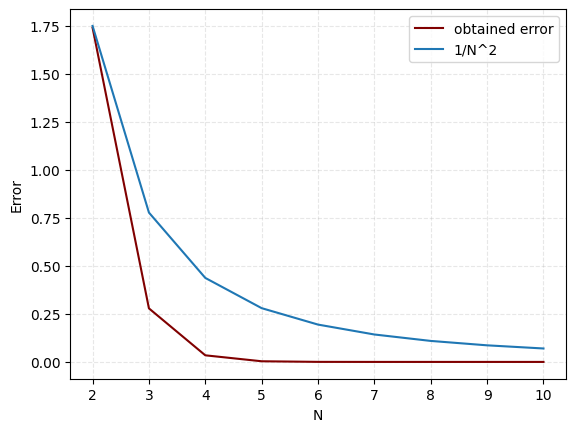

In [103]:
# Convergence Analysis
I = []
error = []
N_values = list(range(2,11))
print('------------------------------------------------------------')
print('N \t \t I \t\t\t error')
print('------------------------------------------------------------')

for N in N_values:
    Integ, err = trapezoid(a, b, I_exact, N)
    I.append(Integ)
    error.append(err)
    print(f'{N} \t {Integ} \t {err}')

# Plotting the error and Comparing with 1/N^2
y_values = 1 / (np.array(N_values) * np.array(N_values))
plt.plot(N_values,error,'maroon',label='obtained error')
plt.plot(N_values,7 * y_values, label = '1/N^2')   # scaling 1/N^2 for proper comparison
plt.grid(True, linestyle='--',alpha = 0.3)
plt.xlabel('N')
plt.ylabel('Error')
plt.legend()

As clear from the figure, the convergence of error in this case is even better than ~$\dfrac{1}{N^2}$